### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 41.9       #  (submerged pipe weight) [kg/m]
N = 50       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 449*1000
Fy_0 = 0.7*Fx_0
LTD = 387

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.2731 # Outer diameter of pipe, [m]
dI= (273.1-15.9*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3

In [14]:
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 90 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
# diag_CR = 1e7*np.array([1, 1, 1])        
diag_CR = 1e5*np.array([1, 1, 1])                  ### !!! ### !!! ### !!! ### affects bending strain
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.25095719, 0.72411745, 0.10073985, 0.88590958, 0.42992306,
       0.88218422, 0.21737777, 0.30845896, 0.93233219, 0.93696849,
       0.30758393, 0.78497149, 0.81434242, 0.53547794, 0.91694302,
       0.48218062, 0.0715714 , 0.93308317, 0.27275175, 0.1406708 ,
       0.45104154, 0.73645024, 0.3721394 , 0.51868803, 0.53218519,
       0.77513773, 0.37654128, 0.99064014, 0.64445059, 0.83829955,
       0.76213755, 0.91187797, 0.93196729, 0.68031297, 0.07935358,
       0.55277374, 0.71750385, 0.26848991, 0.84819109, 0.03128731,
       0.1992976 , 0.64298234, 0.97773515, 0.00664105, 0.53053019,
       0.70880339, 0.35714571, 0.10819975, 0.49304761, 0.09576379])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 10)

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.99538874,  0.        ,  0.0929184 ],
        [ 0.        ,  1.        , -0.24833128],
        [-0.09592318,  0.        ,  0.96420835]],

       [[ 0.9866637 ,  0.        ,  0.12193   ],
        [ 0.        ,  1.        , -0.66247459],
        [-0.16277205,  0.        ,  0.73909437]],

       [[ 0.80511519,  0.        ,  0.59011138],
        [ 0.        ,  1.        , -0.10056954],
        [-0.59311848,  0.        ,  0.80103328]],

       [[ 0.83781419,  0.        ,  0.34536341],
        [ 0.        ,  1.        , -0.7744907 ],
        [-0.54595548,  0.        ,  0.52998894]],

       [[ 0.88896763,  0.        ,  0.41629377],
        [ 0.        ,  1.        , -0.41680087],
        [-0.45797004,  0.        ,  0.80806964]],

       [[ 0.73763128,  0.        ,  0.42906913],
        [ 0.        ,  1.        , -0.77212872],
        [-0.67520374,  0.        ,  0.46873972]],

       [[ 0.98868212,  0.        ,  0.14649488],
        [ 0.        ,  1.        , -0.21566985],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-0.08987796,  0.        ,  0.8899106 ],
        [ 0.        ,  0.        , -0.55028082],
        [-0.93265794,  0.        , -0.227483  ]],

       [[-0.04501817,  0.        ,  0.16392522],
        [ 0.        ,  0.        , -0.28125648],
        [-0.27288342,  0.        , -0.27914253]],

       [[-0.17257603,  0.        ,  0.23071587],
        [ 0.        ,  0.        , -0.03929454],
        [-0.23425941,  0.        , -0.17489897]],

       [[-0.1872735 ,  0.        ,  0.0158762 ],
        [ 0.        ,  0.        , -0.24822505],
        [-0.2873868 ,  0.        , -0.37308524]],

       [[-0.09209603,  0.        ,  0.06910076],
        [ 0.        ,  0.        , -0.44477379],
        [-0.178768  ,  0.        , -0.26501221]],

       [[-0.50419564,  0.        ,  0.23036727],
        [ 0.        ,  0.        , -0.14584774],
        [-0.55081223,  0.        , -0.45111754]],

       [[-0.07473155,  0.        ,  0.4635881 ],
        [ 0.        ,  0.        , -0.52238641],
        

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.59892901,  0.84751992,  0.29285405],
       [ 0.47662179, -0.30023205,  0.58239976],
       [ 0.45586622,  0.21869212,  0.55221689],
       [ 0.60478901, -0.27599399,  0.20936335],
       [ 0.79934537, -0.16372006,  0.48319949],
       [ 0.51934377,  0.11680472,  0.22744428],
       [ 0.65669313,  0.31002017,  0.76176637],
       [ 0.69762439,  0.69537584,  0.32575008],
       [ 0.2297167 ,  0.21601053, -0.09885649],
       [ 0.05079328,  0.20330412,  0.00750981],
       [ 0.14503033,  0.52497747, -0.00726432],
       [ 0.20933809,  0.87679076, -0.15809375],
       [ 0.17982009,  0.74457816,  0.04398194],
       [ 0.67809668,  0.37462493, -0.27374151],
       [ 0.33856766, -0.3059714 ,  0.44748557],
       [ 0.50285287, -0.12263288,  0.4608186 ],
       [ 0.73984368,  0.03608037,  0.3239778 ],
       [ 0.35475645,  0.3110272 ,  0.27995196],
       [ 0.79239107,  0.71596665, -0.56270644],
       [ 0.9681298 ,  0.8117162 ,  0.2341838 ],
       [ 0.29135883,  0.28193202, -0.032

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 1.22011827e+00,  2.34660526e-01, -1.67118391e-01],
       [ 1.00772426e+00,  2.05316208e-01, -4.83928324e-01],
       [ 1.11143149e+00,  7.68628333e-01,  1.66003389e-01],
       [ 5.38913683e-01, -3.23339307e-01, -1.01004661e-01],
       [ 5.42838475e-01,  1.59934468e-02, -6.17280866e-02],
       [ 1.09143598e+00,  4.58420188e-02, -6.28184418e-01],
       [ 1.35362867e+00,  3.52736201e-01, -2.38052747e-01],
       [ 6.63273009e-01,  2.17556404e-01, -1.28973654e-01],
       [ 7.65809667e-01,  9.93174600e-02, -5.95399924e-01],
       [ 5.28018008e-01, -4.01029083e-03, -9.91274880e-02],
       [ 7.41098390e-01,  4.28667139e-01,  7.74037116e-03],
       [ 1.82895189e-01,  2.39885590e-01, -4.35885334e-01],
       [ 9.17787522e-01,  3.85279994e-01, -4.37832222e-01],
       [ 7.79451613e-01,  6.24531242e-01, -4.39727884e-01],
       [ 2.19266499e-01, -2.42815334e-01,  3.15308263e-02],
       [ 3.86226024e-01,  1.30818815e-01,  3.47387368e-02],
       [ 1.51246088e-01, -1.37643775e-03

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[0.72350703, 0.21902808, 0.52077149],
       [0.16910644, 0.64185436, 0.31164615],
       [0.56083758, 0.63391634, 0.1367737 ],
       [0.21940182, 0.95767422, 0.17664607],
       [0.31201898, 0.86379296, 0.12619294],
       [0.63920682, 0.31273251, 0.9442836 ],
       [0.74426167, 0.22808289, 0.18376504],
       [0.52543724, 0.81412894, 0.31691344],
       [0.28725492, 0.99638761, 0.58039305],
       [0.14897549, 0.34617045, 0.50600204],
       [0.84281788, 0.12184477, 0.55456437],
       [0.52529503, 0.27009241, 0.2713049 ],
       [0.65729762, 0.03889629, 0.61545104],
       [0.67305658, 0.52992253, 0.04161948],
       [0.76267821, 0.5646522 , 0.69177078],
       [0.62046696, 0.94400166, 0.22559537],
       [0.54699067, 0.59143689, 0.83954863],
       [0.75306945, 0.78967499, 0.63840879],
       [0.35642478, 0.75627043, 0.07146149],
       [0.38401948, 0.3461977 , 0.88617152],
       [0.30574704, 0.96345894, 0.27501154],
       [0.51539033, 0.04553074, 0.72859157],
       [0.

In [44]:
theta(φ,θ,ψ)

array([[0.25095719, 0.09607089, 0.69556281],
       [0.72411745, 0.16349952, 0.48569964],
       [0.10073985, 0.63492667, 0.2613414 ],
       [0.88590958, 0.57752913, 0.40614059],
       [0.42992306, 0.47571035, 0.09686826],
       [0.88218422, 0.74124088, 0.16209499],
       [0.21737777, 0.1505941 , 0.03827305],
       [0.30845896, 0.22057449, 0.3228386 ],
       [0.93233219, 0.96213222, 0.18373464],
       [0.93696849, 0.6563146 , 0.53876018],
       [0.30758393, 0.21494966, 0.3439769 ],
       [0.78497149, 0.83481301, 0.4332193 ],
       [0.81434242, 0.57279411, 0.81613834],
       [0.53547794, 0.5336759 , 0.60978619],
       [0.91694302, 0.03180161, 0.67035335],
       [0.48218062, 0.25309091, 0.08252188],
       [0.0715714 , 0.05573539, 0.92914877],
       [0.93308317, 0.17123351, 0.21593744],
       [0.27275175, 0.83103953, 0.40004466],
       [0.1406708 , 0.26884164, 0.87854392],
       [0.45104154, 0.67882998, 0.02424798],
       [0.73645024, 0.5054703 , 0.99271546],
       [0.

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 0.79102924, -0.12573161,  0.22378305],
       [ 0.31936751,  0.58940381,  0.1448228 ],
       [ 0.52047622,  0.56116701, -0.2388679 ],
       [ 0.26725668,  0.91922794, -0.08022933],
       [ 0.29398782,  0.82505415, -0.15921988],
       [ 0.84136385, -0.25058842,  0.52443615],
       [ 0.75555111,  0.10359514, -0.03661077],
       [ 0.56006552,  0.65516791, -0.19384641],
       [ 0.6233597 ,  0.83195025,  0.06127405],
       [ 0.30992191,  0.27106707,  0.42016622],
       [ 0.88141717, -0.29214917,  0.26381132],
       [ 0.56888095,  0.1340416 ,  0.0860573 ],
       [ 0.67574671, -0.33713184,  0.46129099],
       [ 0.59719378,  0.50397782, -0.31212786],
       [ 0.91192842,  0.08673528,  0.0143816 ],
       [ 0.51259202,  0.8128371 , -0.39486427],
       [ 0.85387518,  0.15477141,  0.29027769],
       [ 0.86097909,  0.35307907, -0.20682938],
       [ 0.30521932,  0.73133567, -0.19586933],
       [ 0.64003334,  0.01419335,  0.642574  ],
       [ 0.38984246,  0.88067891, -0.101

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 0.77941787, -0.61957562,  0.0929184 ],
        [ 0.6207441 ,  0.7436453 , -0.24833128],
        [ 0.08476168,  0.25123239,  0.96420835]],

       [[ 0.92289369, -0.36524008,  0.12193   ],
        [ 0.34969297,  0.66245169, -0.66247459],
        [ 0.16118954,  0.65403168,  0.73909437]],

       [[ 0.79318899, -0.15039875,  0.59011138],
        [ 0.25706668,  0.96114645, -0.10056954],
        [-0.55205793,  0.23146863,  0.80103328]],

       [[ 0.93670905,  0.05744803,  0.34536341],
        [ 0.24991346,  0.58112599, -0.7744907 ],
        [-0.24519262,  0.81178341,  0.52998894]],

       [[ 0.90326163,  0.1040093 ,  0.41629377],
        [ 0.0879154 ,  0.90473638, -0.41680087],
        [-0.41998728,  0.41307886,  0.80806964]],

       [[ 0.81209963,  0.39546665,  0.42906913],
        [ 0.1025554 ,  0.62713606, -0.77212872],
        [-0.57443588,  0.6710488 ,  0.46873972]],

       [[ 0.98919615, -0.00549835,  0.14649488],
        [ 0.03736322,  0.97575125, -0.21566985],
        

In [49]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[-1.81544310e-01,  3.04069462e-01,  1.24332524e-01],
       [-2.04081069e-01, -2.00341383e-01,  5.23354495e-01],
       [-1.15826809e-02,  5.17104520e-02, -1.92172164e-01],
       [ 3.03510059e-01, -2.14780262e-01,  7.87443847e-01],
       [ 1.57395577e-01, -9.03285119e-02,  2.29131086e-01],
       [ 7.44275637e-01, -1.01232440e+00, -1.68550334e-01],
       [ 2.51678417e-02, -3.72966867e-02, -5.56402002e-02],
       [-1.50574006e-01,  5.53406120e-03,  2.35432587e-01],
       [ 1.17253465e+00, -5.63271843e-01,  3.86670274e-01],
       [ 2.22846608e-01, -5.21644546e-01,  2.91262156e-01],
       [ 3.04186860e-02,  9.22210504e-03, -4.82560351e-02],
       [ 2.44987038e-01, -4.02137364e-01, -7.39987623e-02],
       [-1.39213647e-02, -5.88723175e-01,  5.20750197e-02],
       [-8.56511883e-02,  9.02586779e-02,  2.35898857e-01],
       [-5.59738463e-01, -3.54379647e-01,  9.06371866e-01],
       [ 9.56189451e-02, -1.40436519e-01,  3.24669391e-01],
       [-5.53906943e-01,  4.00628665e-01

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[-1.15440173e-01, -5.64385647e-02,  4.94457786e-02],
       [-1.16290505e-01, -2.01183698e-01,  2.41098431e-01],
       [ 6.40835284e-02, -4.64309513e-02,  8.81011733e-02],
       [ 2.61824377e-01, -5.96209862e-01,  2.76691967e-01],
       [ 9.85968589e-02, -9.19237065e-02,  1.38331652e-02],
       [ 4.85067322e-01, -5.75201193e-01, -9.59993701e-03],
       [ 4.79462679e-03, -7.49733737e-03,  2.26816234e-03],
       [-1.17507990e-02, -4.71304841e-02,  4.34285788e-02],
       [ 8.25363076e-01, -7.69217456e-01, -1.60142148e-01],
       [ 3.29047751e-01, -8.03674170e-01,  4.06777866e-01],
       [-1.66282756e-02, -4.90839514e-02,  4.55413402e-02],
       [ 5.42948214e-01, -6.21893018e-01,  2.14592271e-01],
       [-3.37785902e-02, -7.82378609e-01,  5.82804624e-01],
       [ 4.01113716e-02, -3.47891472e-01,  2.69246079e-01],
       [-3.47403271e-01, -2.76102540e-01,  4.88293987e-01],
       [ 3.03703231e-02, -6.41198865e-02,  1.91970762e-02],
       [-6.13010906e-02, -4.84246436e-02

In [52]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
    t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [53]:
ne(x, y, z, φ, θ, ψ)

array([[-1.81544310e+08,  3.04069462e+08,  1.24332524e+08],
       [-2.04081069e+08, -2.00341383e+08,  5.23354495e+08],
       [-1.15826809e+07,  5.17104520e+07, -1.92172164e+08],
       [ 3.03510059e+08, -2.14780262e+08,  7.87443847e+08],
       [ 1.57395577e+08, -9.03285119e+07,  2.29131086e+08],
       [ 7.44275637e+08, -1.01232440e+09, -1.68550334e+08],
       [ 2.51678417e+07, -3.72966867e+07, -5.56402002e+07],
       [-1.50574006e+08,  5.53406120e+06,  2.35432587e+08],
       [ 1.17253465e+09, -5.63271843e+08,  3.86670274e+08],
       [ 2.22846608e+08, -5.21644546e+08,  2.91262156e+08],
       [ 3.04186860e+07,  9.22210504e+06, -4.82560351e+07],
       [ 2.44987038e+08, -4.02137364e+08, -7.39987623e+07],
       [-1.39213647e+07, -5.88723175e+08,  5.20750197e+07],
       [-8.56511883e+07,  9.02586779e+07,  2.35898857e+08],
       [-5.59738463e+08, -3.54379647e+08,  9.06371866e+08],
       [ 9.56189451e+07, -1.40436519e+08,  3.24669391e+08],
       [-5.53906943e+08,  4.00628665e+08

In [54]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[-2.06140973e+08, -1.56479562e+08,  8.16917016e+07],
       [-3.45235852e+07, -4.54116178e+08, -1.87299190e+08],
       [-1.24699869e+08,  4.34907549e+07,  1.92186284e+07],
       [ 1.49428929e+08, -7.76381559e+08, -2.69358404e+08],
       [ 8.90345431e+07, -1.15480508e+08, -1.06684895e+08],
       [-6.29919334e+08, -2.65377627e+08, -1.18768894e+09],
       [-7.75805118e+06,  1.23791740e+07, -1.18072109e+07],
       [ 2.75679267e+07, -1.21739180e+08,  2.04930222e+07],
       [-8.06012202e+07, -1.06432072e+09, -1.30600722e+09],
       [-1.01663214e+08, -3.43993190e+08, -5.38301548e+08],
       [-7.69587158e+06,  2.56226570e+07,  4.55182996e+04],
       [-1.90346181e+08, -3.63280473e+07, -4.32756995e+08],
       [ 1.62205015e+07, -5.18570948e+07, -5.81923197e+08],
       [ 3.63288954e+07, -1.87026722e+08,  8.47498708e+07],
       [-3.19357173e+08, -1.05421609e+09, -6.09406845e+08],
       [ 6.27317401e+07, -1.62282392e+08, -8.86708687e+07],
       [-3.69959059e+08, -5.20020334e+08

In [55]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [56]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 31443.05464638,  -7665.91114393,  64659.48623774],
       [ 77368.17566945, -15826.41516202,  24111.17928271],
       [ 23532.77198682,  60864.36838464,  14959.24986531],
       [ 88249.37189127,  26297.70227958, -26841.71677876],
       [ 42251.33396726,  43533.55706928, -11861.55798689],
       [ 72027.66331378,  61608.26811041, -51967.37258331],
       [ 22052.43189404,  14233.97555502,    433.71498044],
       [ 36828.57850843,  12256.36923957,  23266.10415402],
       [ 62291.57914791,  81459.11030789, -70228.85835041],
       [ 93700.79610313,  22219.97240096, -31895.58590581],
       [ 37043.18148116,  11080.82974651,  25468.18196346],
       [ 75410.56157645,  52861.14362637, -37606.45055169],
       [ 98795.86541886,  -2076.24316813,   2938.85246475],
       [ 72779.49473247,  22253.11930338,  17910.69750901],
       [ 92944.4058086 , -50028.86277581,  37838.05449894],
       [ 48512.72133152,  21482.4496949 ,  -4995.28085758],
       [ 12308.74094106,  -1070.83255159

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[-2.72848411e-12, -3.64115823e-12,  9.09494702e-13],
       [-9.09494702e-13,  6.13298950e-12,  5.45696821e-12],
       [-3.63797881e-12,  1.47896350e-12, -1.81898940e-12],
       [-1.81898940e-12,  2.95909228e-12, -3.63797881e-12],
       [ 0.00000000e+00,  5.65560559e-13,  3.63797881e-12],
       [ 7.27595761e-12, -8.04460677e-12,  0.00000000e+00],
       [ 7.81597009e-14, -1.11279455e-13, -4.54747351e-13],
       [ 4.54747351e-13,  6.34536873e-13, -9.09494702e-13],
       [-2.91038305e-11,  1.73306979e-11, -7.27595761e-12],
       [-2.72848411e-12,  5.95773381e-12, -3.63797881e-12],
       [-4.54747351e-13, -4.24219981e-12,  1.81898940e-12],
       [ 0.00000000e+00,  3.55658913e-12,  0.00000000e+00],
       [ 1.35003120e-13, -3.96729884e-12, -7.73070497e-12],
       [ 1.36424205e-12, -8.32841981e-12,  5.45696821e-12],
       [ 3.63797881e-12,  1.15452159e-11,  0.00000000e+00],
       [ 0.00000000e+00,  2.01605547e-14,  1.81898940e-12],
       [-2.84217094e-12, -2.74319620e-13

In [58]:
def fD(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[5.58752690e+01, 2.91858819e+02, 2.82331580e+02],
       [2.04122170e+01, 1.52396604e+02, 9.37999711e+01],
       [6.47572693e-01, 4.97934786e+01, 4.00816987e+01],
       [2.69008998e+01, 3.20912666e+01, 9.61836140e+01],
       [5.23566008e+01, 6.22791016e+00, 1.46195599e+01],
       [4.86663588e+01, 1.83259851e+01, 1.65614177e+02],
       [1.84794742e+02, 2.27746788e+02, 1.94226064e+02],
       [3.46909073e+01, 1.53888508e+01, 1.86253143e+02],
       [6.14387933e+00, 1.10382879e+02, 7.85000803e+00],
       [2.01999195e+02, 6.19815648e+01, 2.03562449e+02],
       [6.20475929e+00, 1.18858381e+01, 6.47692452e+01],
       [7.66874385e+01, 1.95567466e+00, 8.38690733e+01],
       [3.06455025e-01, 3.29165165e+01, 3.17581103e+01],
       [6.33001467e+01, 2.36741940e+01, 2.80854066e+01],
       [1.70237613e+00, 6.05258341e+01, 7.42403913e+01],
       [4.69847325e+01, 5.45330198e+01, 1.36729669e+02],
       [1.18584214e+02, 1.93548718e+00, 6.56418850e-03],
       [6.86514882e+01, 1.96630

In [60]:
fg_e = np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = np.sum(phi(x,y,z) * e3, axis=1)+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        if k[i]<0:
            k0[i]=0
        elif 0<=k[i]<=d0/20:
            k0[i]=(fg_e2*10*k[i]**2)/((d0/8-d0/40)*(d0))
        else:
            k0[i]=(fg_e2*(k[i]-d0/40))/(d0/8-d0/40)
            
    result = k0[:, np.newaxis] * e3 
    result[1:,:]=0
    return result        

In [63]:
sigma(x,y,z)

array([[    0.        ,     0.        , 29975.56441586],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0. 

In [64]:
def ne_hat(x,y,z,dx,dy,dz, flag):
    ans = fg_e.T - fD(dx,dy,dz)  - sigma(x,y,z).T
    return ans

In [65]:
ne_hat(x,y,z,dx,dy,dz, False).T

array([[-5.58752690e+01, -2.91858819e+02, -3.04358717e+04],
       [-2.04122170e+01, -1.52396604e+02, -2.71775699e+02],
       [-6.47572693e-01, -4.97934786e+01, -2.18057427e+02],
       [-2.69008998e+01, -3.20912666e+01, -2.74159342e+02],
       [-5.23566008e+01, -6.22791016e+00, -1.92595288e+02],
       [-4.86663588e+01, -1.83259851e+01, -3.43589906e+02],
       [-1.84794742e+02, -2.27746788e+02, -3.72201792e+02],
       [-3.46909073e+01, -1.53888508e+01, -3.64228871e+02],
       [-6.14387933e+00, -1.10382879e+02, -1.85825736e+02],
       [-2.01999195e+02, -6.19815648e+01, -3.81538177e+02],
       [-6.20475929e+00, -1.18858381e+01, -2.42744973e+02],
       [-7.66874385e+01, -1.95567466e+00, -2.61844802e+02],
       [-3.06455025e-01, -3.29165165e+01, -2.09733839e+02],
       [-6.33001467e+01, -2.36741940e+01, -2.06061135e+02],
       [-1.70237613e+00, -6.05258341e+01, -2.52216120e+02],
       [-4.69847325e+01, -5.45330198e+01, -3.14705397e+02],
       [-1.18584214e+02, -1.93548718e+00

In [66]:
def Jrho(Ret,Jrho0): 
    return np.einsum('ijk,kl,iml->ijm', Ret, Jrho0, Ret)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[ 1.00863383e+02, -2.30745453e+00,  8.95926975e+00],
        [-2.30745453e+00,  1.06166842e+02, -2.39443095e+01],
        [ 8.95926975e+00, -2.39443095e+01,  1.92969775e+02]],

       [[ 1.01486692e+02, -8.07755265e+00,  9.01177758e+00],
        [-8.07755265e+00,  1.43887259e+02, -4.89631243e+01],
        [ 9.01177758e+00, -4.89631243e+01,  1.54626049e+02]],

       [[ 1.34823145e+02, -5.93472309e+00,  4.72698860e+01],
        [-5.93472309e+00,  1.01011423e+02, -8.05595495e+00],
        [ 4.72698860e+01, -8.05595495e+00,  1.64165432e+02]],

       [[ 1.11927588e+02, -2.67480747e+01,  1.83038787e+01],
        [-2.67480747e+01,  1.59983584e+02, -4.10471504e+01],
        [ 1.83038787e+01, -4.10471504e+01,  1.28088828e+02]],

       [[ 1.17330050e+02, -1.73511603e+01,  3.36394352e+01],
        [-1.73511603e+01,  1.17372296e+02, -3.36804126e+01],
        [ 3.36394352e+01, -3.36804126e+01,  1.65297654e+02]],

       [[ 1.18410032e+02, -3.31296597e+01,  2.01121744e+01],
        [-3.31

### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 7.93938111184604,
 15.879181626579484,
 23.81982096924257,
 31.761718609188385,
 39.70529408223919,
 47.65096701284832,
 55.59915713626667,
 63.550284320715164,
 71.50476858956407,
 79.46303014352074,
 87.42548938282651,
 95.39256692946427,
 103.36468364937764,
 111.34226067470327,
 119.32571942601683,
 127.31548163459459,
 135.31196936469118,
 143.31560503583512,
 151.32681144514297,
 159.34601178965357,
 167.37362968868317,
 175.41008920620317,
 183.45581487324125,
 191.51123171030702,
 199.57676524984365,
 207.65284155870668,
 215.73988726067074,
 223.83832955896625,
 231.94859625884573,
 240.0711157901832,
 248.20631723010564,
 256.35463032565883,
 264.5164855165091,
 272.69231395768054,
 280.8825475423316,
 289.0876189245693,
 297.3079615423042,
 305.54400964014667,
 313.7961982923462,
 322.0649634257739,
 330.35074184295024,
 338.65397124511946,
 346.97509025537073,
 355.3145384418091,
 363.6727563407748,
 372.05018548011526,
 380.4472684025088,
 388.86444868884166,
 397.302

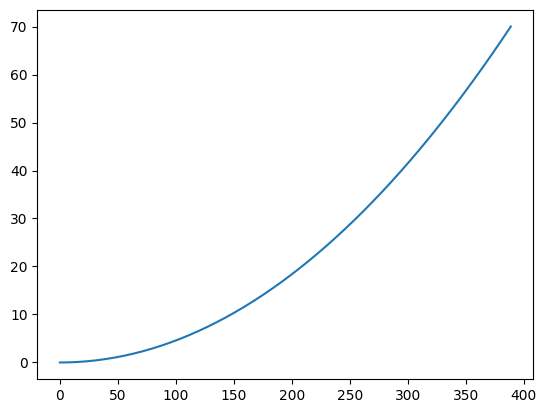

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)
    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz, False).T
    Z = (Z1 + Z2 )


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T)
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    # D[:, :] = 0                                                     ### !!! ### !!! ### !!! ###

    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0, method='lm')

In [83]:
root_

 message: The relative error between two consecutive iterates is at most 0.000000
 success: True
  status: 2
     fun: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
       x: [ 0.000e+00  7.939e+00 ...  0.000e+00  0.000e+00]
   cov_x: None
  method: lm
    nfev: 608
    fjac: [[-1.100e+03  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00 -1.406e+02 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ... -0.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00 ...  0.000e+00 -0.000e+00]]
    ipvt: [201 450 ... 239 240]
     qtf: [-1.469e+02 -7.523e-01 ...  4.502e-17  3.079e-18]

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
q0 = root_.x                                            # start from static solution

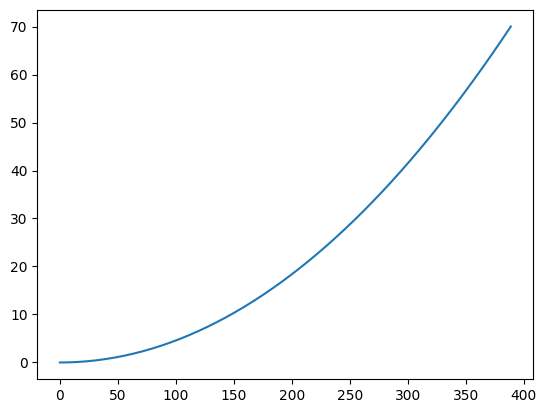

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Vessle Simulation

In [87]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [88]:
Number*sampleTime

600.0

In [89]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [90]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [91]:
simData.shape 

(60001, 24)

In [92]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

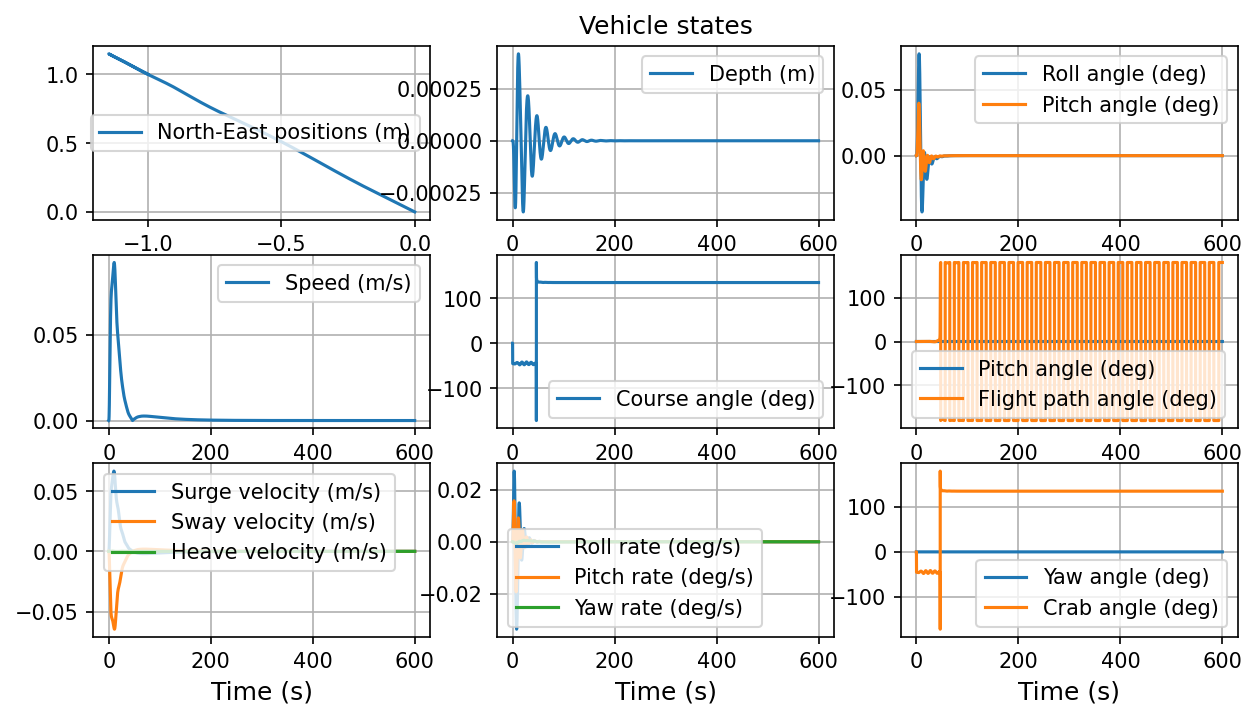

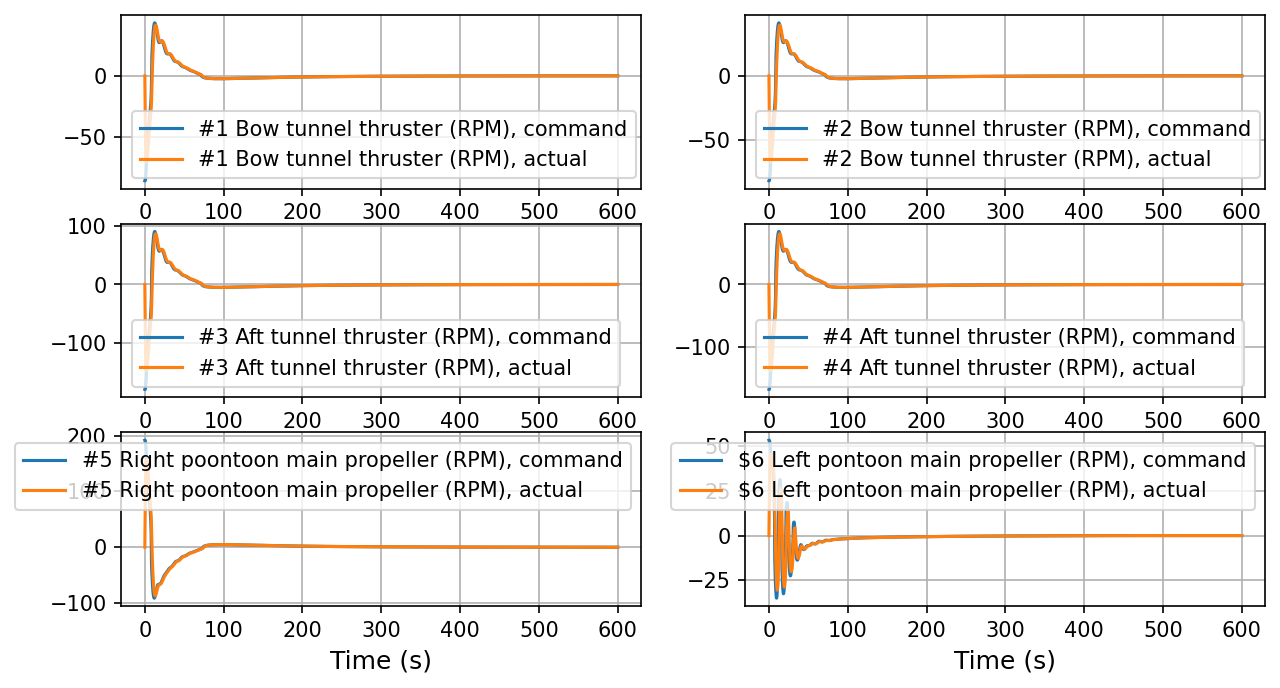

In [93]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [94]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

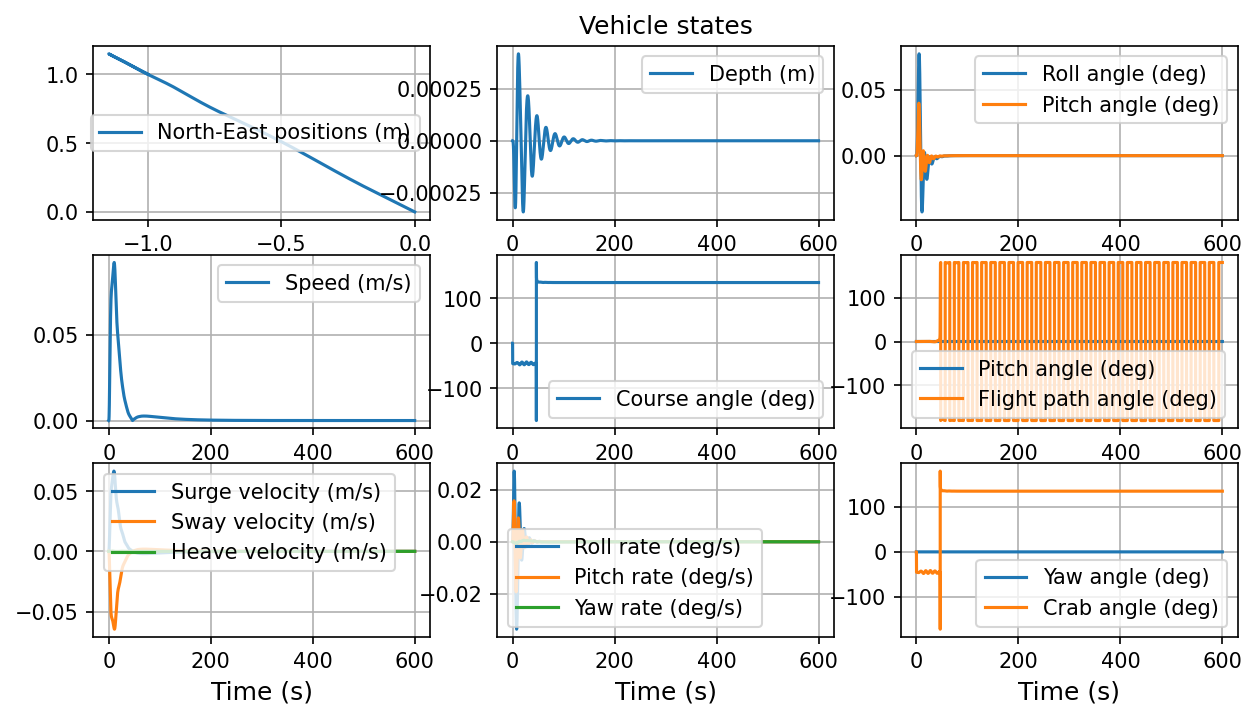

In [95]:
plotVehicleStates(simTime, simData, 3)

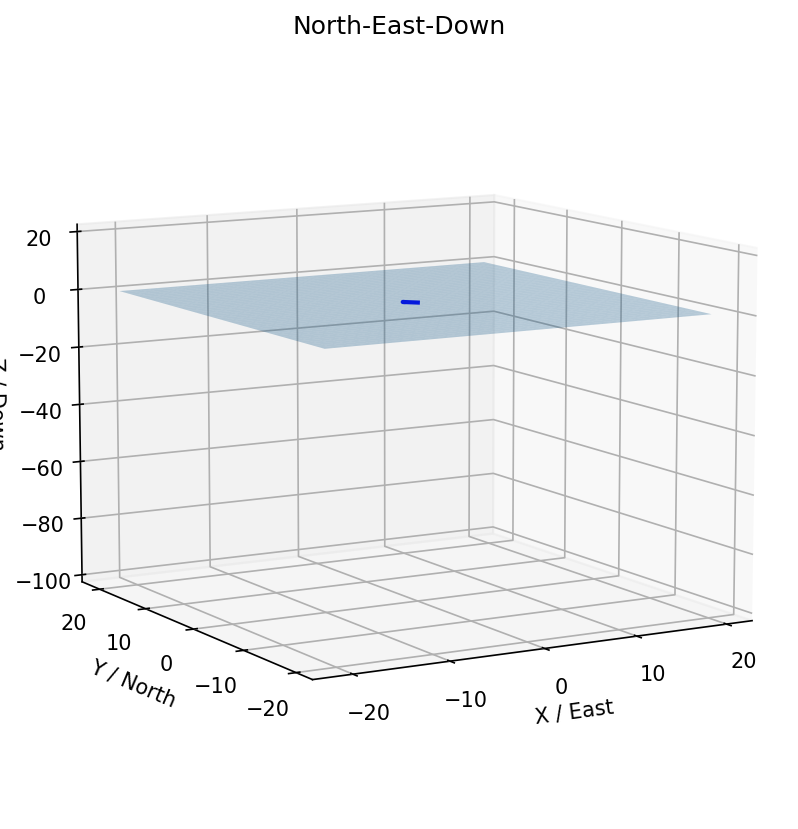

In [96]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [97]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [98]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

### Dynamics

In [99]:
def dynamic_func(t, Q, T):
    
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    
    dx_ve = simData[:, 6][idx]
    dy_ve = simData[:, 7][idx]
    dz_ve = simData[:, 8][idx]
    dphi_ve = ssa(simData[:, 9][idx])
    dtheta_ve = ssa(simData[:, 10][idx])
    dpsi_ve = ssa(simData[:, 11][idx])
    
    s = np.linspace(0, 1, N)
    error_x=0.1*(s*dx_ve-dx)
    error_y=0.1*(s*dy_ve-dy)
    error_z=0.1*(s*dz_ve-dz)
    dx += error_x
    dy += error_y
    dz += error_z
    
    RET = Ret(φ,θ,ψ)
    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz, False).T
    Z = (Z1 + Z2)

############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ).T
    C = C1

    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))

    error_φ=0.1*(s*dphi_ve-dφ)
    error_θ=0.1*(s*dtheta_ve-dθ)
    error_ψ=0.1*(s*dpsi_ve-dψ)
    dφ += error_φ
    dθ += error_θ
    dψ += error_ψ
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################


    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         

    ans=np.concatenate([dx, ddx, 
                            dy, ddy, 
                            dz, ddz, 
                            dφ, ddφ, 
                            dθ, ddθ,  
                            dψ, ddψ, 
                           ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
       
        T.top_tension=max(T.top_tension, np.max(ax[:,0]))            
        
        ben0=np.einsum('ijk,ik->ij',np.linalg.inv(RET), me(φ, θ, ψ, φ, θ, ψ))
        ben=np.max(ben0[:,1:])/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2 + (y[-1]-0)**2 + (z[-1]-z0_[-1])**2)**2)
        
        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagbend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
 
    return ans

In [100]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.00003 for i in range(N)]),
                                          np.array([0.001767*i/N for i in range(N)]))

In [101]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(T_, ), 
               )
print(datetime.now() - startTime1)

Physical time:  6.0376224638449814e-09  Iteration wall-clock time:  0:00:00.020826
Physical time:  1.0020685055134175  Iteration wall-clock time:  0:00:03.283490
Physical time:  2.008108238428629  Iteration wall-clock time:  0:00:03.135492
Physical time:  3.0017685416131528  Iteration wall-clock time:  0:00:03.248465
Physical time:  4.002804663532124  Iteration wall-clock time:  0:00:03.410943
Physical time:  5.002343095623281  Iteration wall-clock time:  0:00:03.076242
Physical time:  6.006784976093877  Iteration wall-clock time:  0:00:03.080908
Physical time:  7.000095725587587  Iteration wall-clock time:  0:00:03.677955
Physical time:  8.000163516651707  Iteration wall-clock time:  0:00:04.670275
Physical time:  9.01249194688978  Iteration wall-clock time:  0:00:03.425438
0:00:33.549748


In [102]:
# max axial tension
T_.top_tension

314711.8773089406

In [103]:
# max bending strain
T_.sagbend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.01949595401944095

### Results

In [104]:
fin=us_

In [105]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.038e-07 ...  9.993e+00  1.000e+01]
        y: [[ 0.000e+00  4.717e-26 ...  5.433e-03  5.437e-03]
            [ 7.939e+00  7.939e+00 ...  7.921e+00  7.921e+00]
            ...
            [ 0.000e+00  7.488e-24 ... -7.213e-06 -7.245e-06]
            [ 0.000e+00 -1.275e-21 ... -7.363e-06 -7.396e-06]]
      sol: None
 t_events: None
 y_events: None
     nfev: 3068
     njev: 0
      nlu: 0

In [106]:
t=fin.t

In [107]:
fin=fin.y.T

In [108]:
t.shape, fin.shape

((500,), (500, 600))

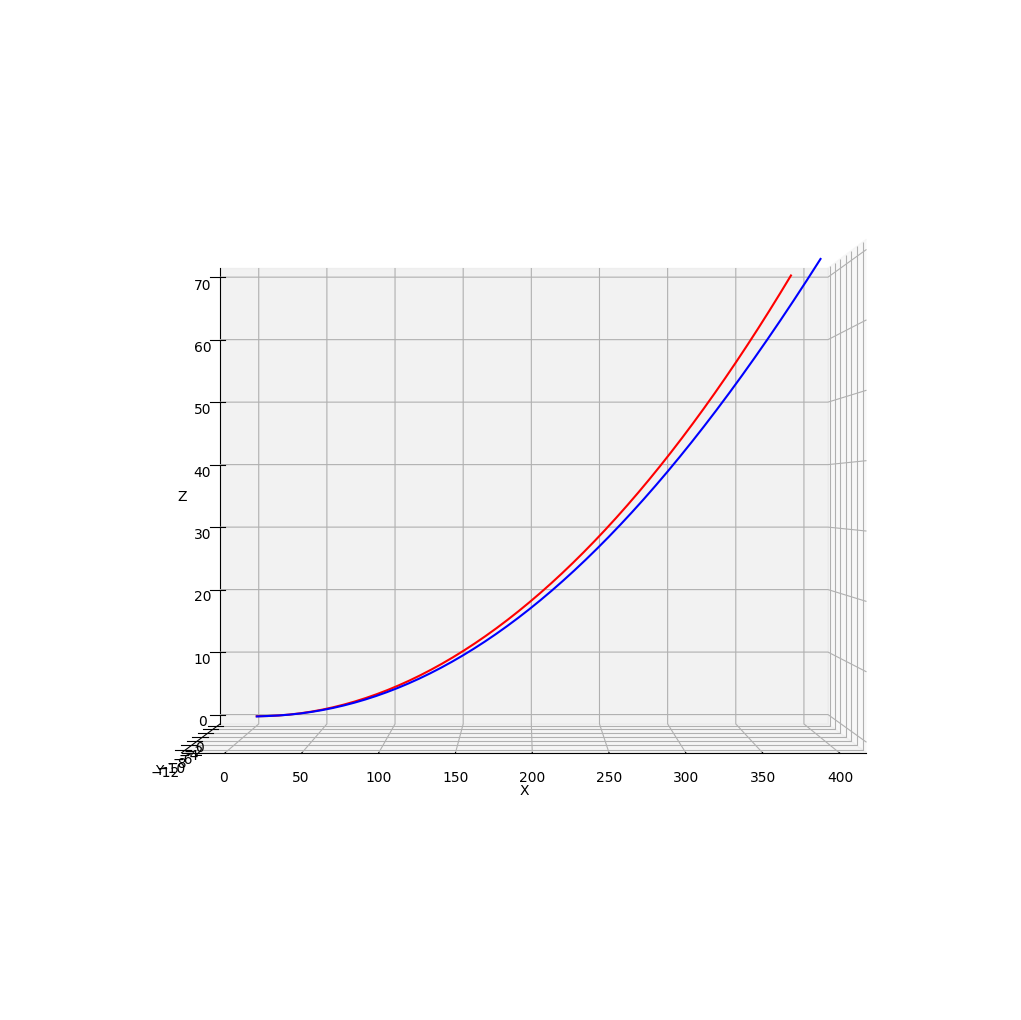

In [109]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [110]:
X,Y,Z

(array([5.43749990e-03, 7.92145201e+00, 1.58428513e+01, 2.37644995e+01,
        3.16864808e+01, 3.96088907e+01, 4.75318323e+01, 5.54554148e+01,
        6.33797528e+01, 7.13049644e+01, 7.92311647e+01, 8.71584642e+01,
        9.50869696e+01, 1.03016780e+02, 1.10947974e+02, 1.18880603e+02,
        1.26814679e+02, 1.34750175e+02, 1.42687027e+02, 1.50625131e+02,
        1.58564335e+02, 1.66504465e+02, 1.74445340e+02, 1.82386769e+02,
        1.90328636e+02, 1.98270817e+02, 2.06213151e+02, 2.14155600e+02,
        2.22098250e+02, 2.30041389e+02, 2.37985255e+02, 2.45929878e+02,
        2.53875364e+02, 2.61821963e+02, 2.69769969e+02, 2.77719729e+02,
        2.85671872e+02, 2.93626722e+02, 3.01584375e+02, 3.09545111e+02,
        3.17509355e+02, 3.25477098e+02, 3.33447009e+02, 3.41418044e+02,
        3.49390153e+02, 3.57363265e+02, 3.65337464e+02, 3.73313103e+02,
        3.81291424e+02, 3.89274544e+02]),
 array([ 1.63125026e-05,  1.84368287e-02,  2.62003716e-02,  2.32544286e-02,
         9.5617294

In [111]:
X0,Y0,Z0

(array([  0.        ,   7.93932869,  15.87865737,  23.81798606,
         31.75731475,  39.69664344,  47.63597212,  55.57530081,
         63.5146295 ,  71.45395818,  79.39328687,  87.33261556,
         95.27194424, 103.21127293, 111.15060162, 119.08993031,
        127.02925899, 134.96858768, 142.90791637, 150.84724505,
        158.78657374, 166.72590243, 174.66523111, 182.6045598 ,
        190.54388849, 198.48321718, 206.42254586, 214.36187455,
        222.30120324, 230.24053192, 238.17986061, 246.1191893 ,
        254.05851798, 261.99784667, 269.93717536, 277.87650405,
        285.81583273, 293.75516142, 301.69449011, 309.63381879,
        317.57314748, 325.51247617, 333.45180485, 341.39113354,
        349.33046223, 357.26979092, 365.2091196 , 373.14844829,
        381.08777698, 389.02710566]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.

In [112]:
us=fin.T

In [113]:
us.shape

(600, 500)

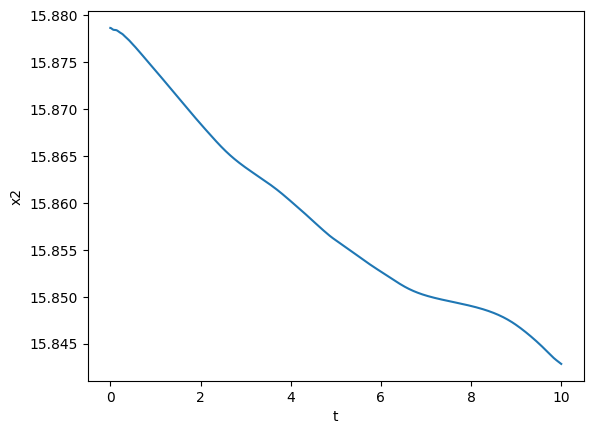

In [114]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

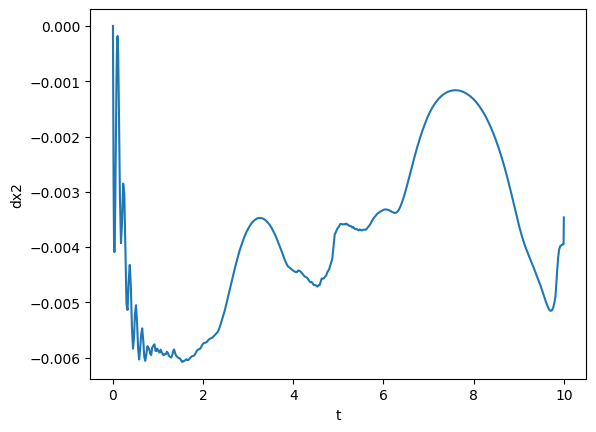

In [115]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

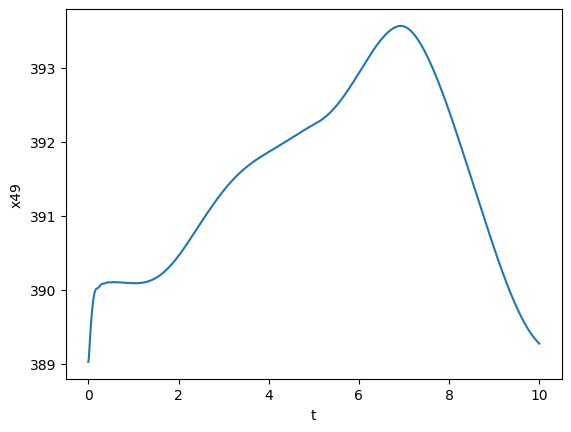

In [116]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

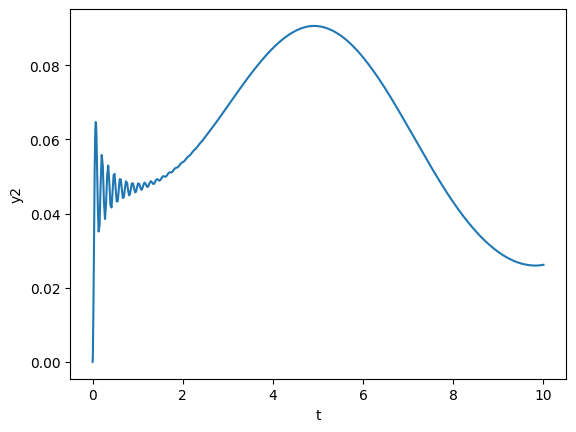

In [117]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

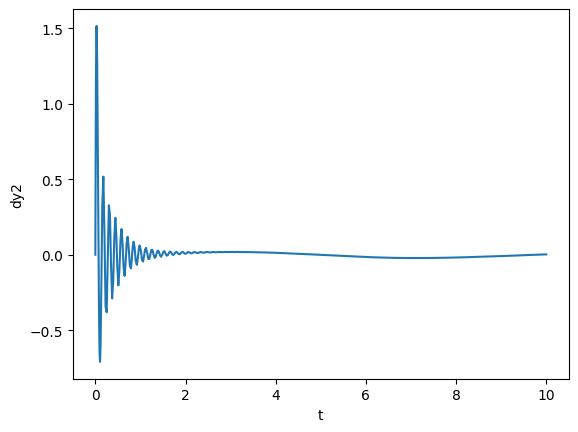

In [118]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

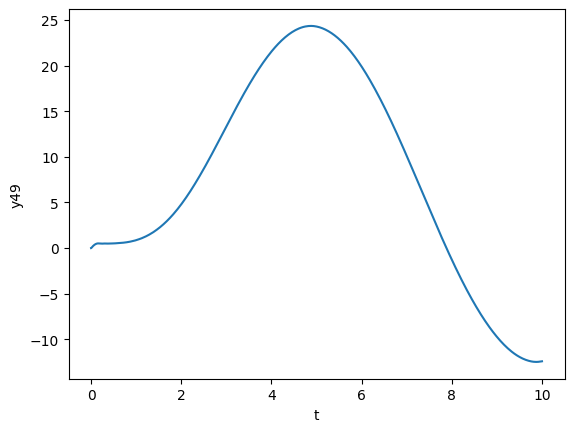

In [119]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

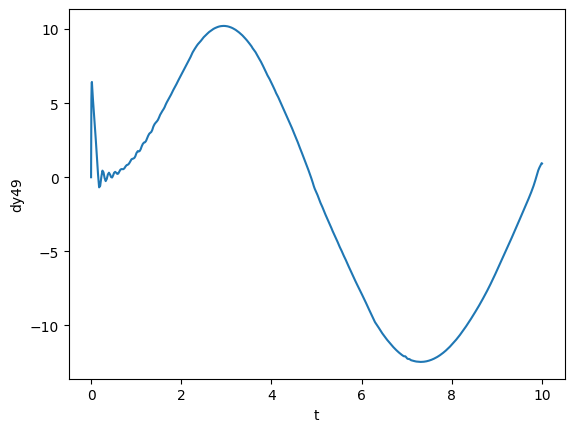

In [120]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

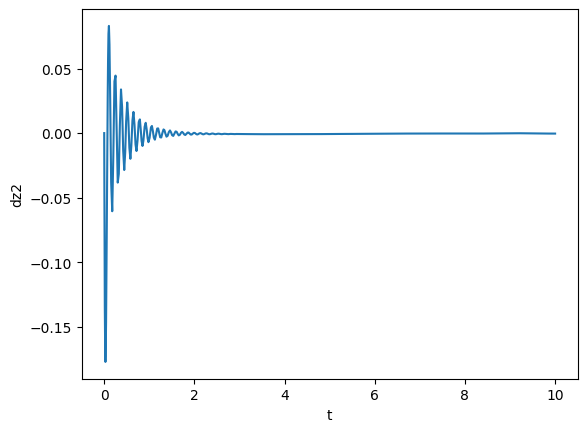

In [121]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

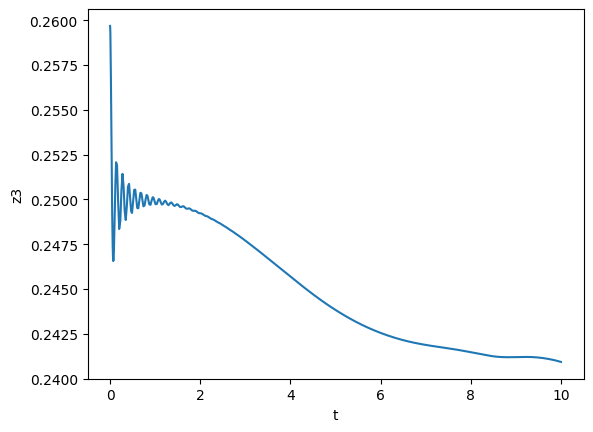

In [122]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

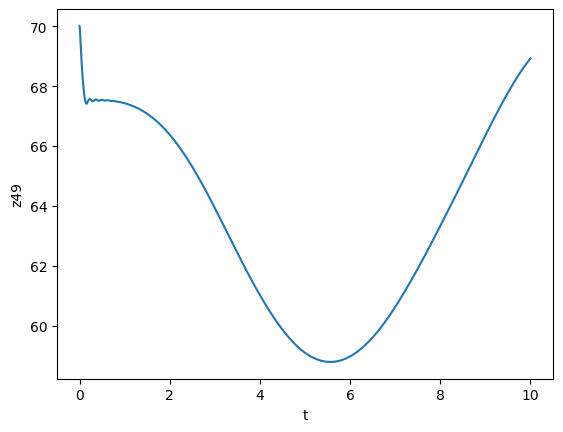

In [123]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

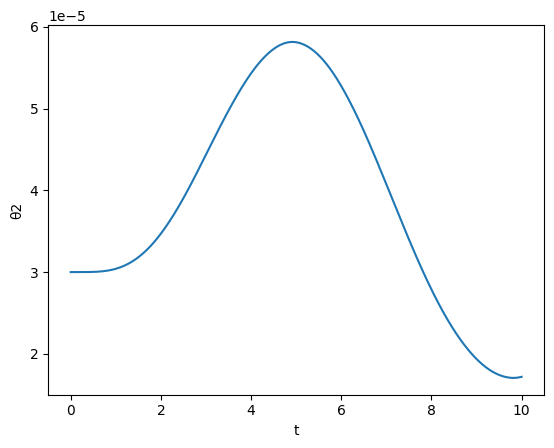

In [124]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

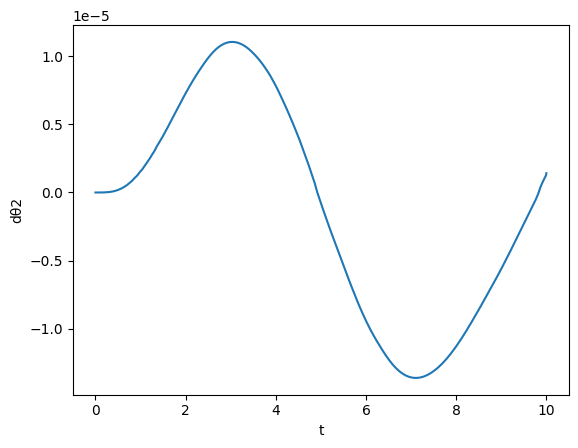

In [125]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

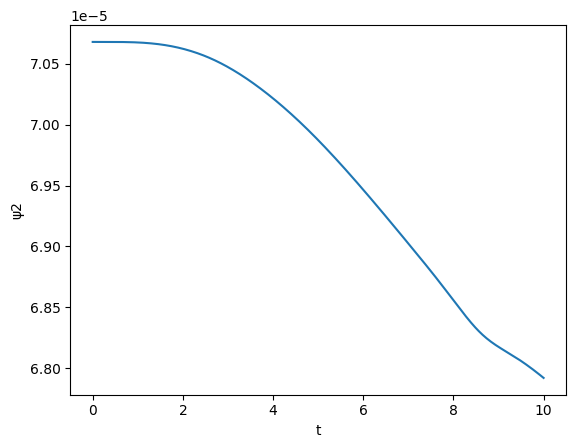

In [126]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

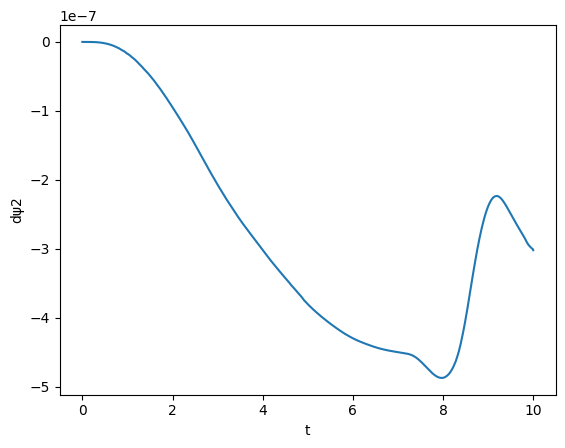

In [127]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

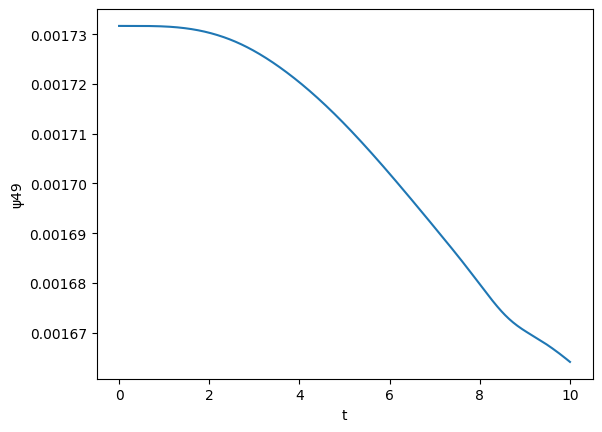

In [128]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [129]:
X010=us.T[:,0*N:1*N]

In [130]:
Y010=us.T[:,2*N:3*N]

In [131]:
Z010=us.T[:,4*N:5*N]

In [132]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()